# 03 - EDA visual e tecnica

Este notebook organiza a analise exploratoria visual e tecnica do dataset apos indexacao, split por grupo e auditoria de qualidade.

A EDA aqui e descritiva. Ela busca entender distribuicao de classes, quantidade de slices por grupo, estatisticas simples de intensidade e exemplos visuais. Nao ha modelagem nesta etapa.


## tl;dr

- A unidade de entrada visual e o slice JPEG, mas a avaliacao deve respeitar grupos inferidos.
- A EDA compara classes por slice e por grupo.
- Estatisticas de intensidade sao apenas pixels JPEG, nao HU.
- Figuras existentes em `reports/figures/` sao reutilizadas quando disponiveis.
- Riscos acompanhados: desbalanceamento, variabilidade por grupo, atalhos visuais e diferencas tecnicas entre classes.


## Contexto & Metodos

Script que gera tabelas e figuras principais desta etapa:

```bash
python scripts/run_visual_eda.py
```

Entradas esperadas:

- `data/interim/split_slices.csv`.
- `data/interim/image_quality_audit.csv`.

Saidas derivadas reaproveitadas:

- `reports/tables/eda_image_summary_by_class.csv`.
- `reports/tables/eda_image_summary_by_split_class.csv`.
- figuras `eda_*.png` em `reports/figures/`.

### Key Assumptions

- Analise descritiva: descreve distribuicoes e exemplos, nao estima efeito causal.
- Nao ha tratamento ou controle experimental.
- Outcome futuro da modelagem: classe binaria `Hepatic_Steatosis` versus `Healthy`.
- Risco de leakage continua sendo controlado pelo split por `inferred_group_id`.


## Setup

Carregamos bibliotecas, caminhos e pequenas funcoes auxiliares.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 30)


def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Arquivo nao encontrado: {path}")
        return None
    return pd.read_csv(path)


## Data

Carregamos split, auditoria e tabelas de EDA ja geradas.


In [2]:
split_slices = read_csv_if_exists(DATA_INTERIM / "split_slices.csv")
audit_df = read_csv_if_exists(DATA_INTERIM / "image_quality_audit.csv")
eda_by_class = read_csv_if_exists(REPORT_TABLES / "eda_image_summary_by_class.csv")
eda_by_split_class = read_csv_if_exists(REPORT_TABLES / "eda_image_summary_by_split_class.csv")

if audit_df is None:
    print("Para gerar a base de auditoria: python scripts/audit_images.py")
if eda_by_class is None:
    print("Para gerar tabelas e figuras de EDA: python scripts/run_visual_eda.py")


## Distribuicao de classes por slice

Esta tabela mostra o balanceamento no nivel de imagem/slice.


In [3]:
source_for_classes = split_slices if split_slices is not None else audit_df
if source_for_classes is not None:
    class_by_slice = (
        source_for_classes.groupby("class_name")
        .size()
        .reset_index(name="n_slices")
        .sort_values("class_name")
    )
    class_by_slice["share"] = class_by_slice["n_slices"] / class_by_slice["n_slices"].sum()
    display(class_by_slice)


,class_name,n_slices,share
0,Healthy,1611,0.45291
1,Hepatic_Steatosis,1946,0.54709


## Distribuicao de classes por grupo

Como varios slices podem pertencer ao mesmo agrupamento, tambem verificamos a distribuicao por `inferred_group_id`.


In [4]:
if source_for_classes is not None:
    class_by_group = (
        source_for_classes.groupby("class_name")
        .agg(n_groups=("inferred_group_id", "nunique"), n_slices=("filename", "count"))
        .reset_index()
        .sort_values("class_name")
    )
    class_by_group["slices_per_group"] = (class_by_group["n_slices"] / class_by_group["n_groups"]).round(2)
    display(class_by_group)


,class_name,n_groups,n_slices,slices_per_group
0,Healthy,76,1611,21.20
1,Hepatic_Steatosis,149,1946,13.06


## Numero de slices por grupo

Esta distribuicao ajuda a enxergar variabilidade entre agrupamentos. Grupos com muitos slices podem ter peso maior em avaliacoes por slice, por isso a avaliacao por grupo e importante.


,class_name,count,min,mean,median,max
0,Healthy,76,11,21.20,22.5,36
1,Hepatic_Steatosis,149,10,13.06,12.0,24


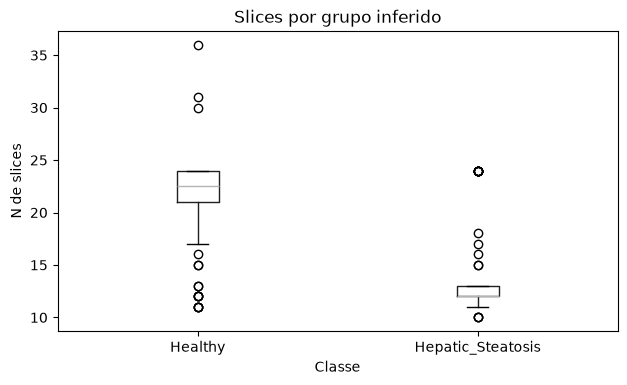

In [5]:
if source_for_classes is not None:
    group_sizes = (
        source_for_classes.groupby(["class_name", "inferred_group_id"])
        .size()
        .reset_index(name="n_slices")
    )
    display(
        group_sizes.groupby("class_name")["n_slices"]
        .agg(["count", "min", "mean", "median", "max"])
        .round(2)
        .reset_index()
    )

    ax = group_sizes.boxplot(column="n_slices", by="class_name", grid=False, figsize=(7, 4))
    ax.set_title("Slices por grupo inferido")
    ax.set_xlabel("Classe")
    ax.set_ylabel("N de slices")
    plt.suptitle("")
    plt.show()


## Estatisticas simples de intensidade

As estatisticas abaixo sao derivadas dos pixels JPEG convertidos para escala de cinza. Elas nao devem ser interpretadas como HU clinico.


In [6]:
if audit_df is not None:
    intensity_columns = ["mean_intensity", "std_intensity", "min_intensity", "max_intensity"]
    existing_columns = [column for column in intensity_columns if column in audit_df.columns]
    summary = (
        audit_df.groupby("class_name")[existing_columns]
        .agg(["mean", "std", "median", "min", "max"])
        .round(4)
    )
    display(summary)


mean_intensity                                    \
                            mean     std   median     min      max   
class_name                                                           
Healthy                  39.4444  8.6777  38.2414  20.391  66.7057   
Hepatic_Steatosis        40.1071  8.3652  39.3808  17.970  63.2120   

                  std_intensity                                     \
                           mean     std   median      min      max   
class_name                                                           
Healthy                 61.2759  4.4717  61.7223  46.6278  70.6277   
Hepatic_Steatosis       58.5789  4.7031  58.4562  42.8936  70.3865   

                  min_intensity                     max_intensity              \
                           mean  std median min max          mean  std median   
class_name                                                                      
Healthy                     0.0  0.0    0.0   0   0         255.0  0.0  255.0   
Hepatic_Steatosis           0.0  0.0    0.0   0   0         255.0  0.0  255.0   

                             
                   min  max  
class_name                   
Healthy            255  255  
Hepatic_Steatosis  255  255

## Histograma de intensidade media

O histograma ajuda a visualizar sobreposicao entre classes. Ele e exploratorio e deve ser lido junto das limitacoes do formato JPEG.


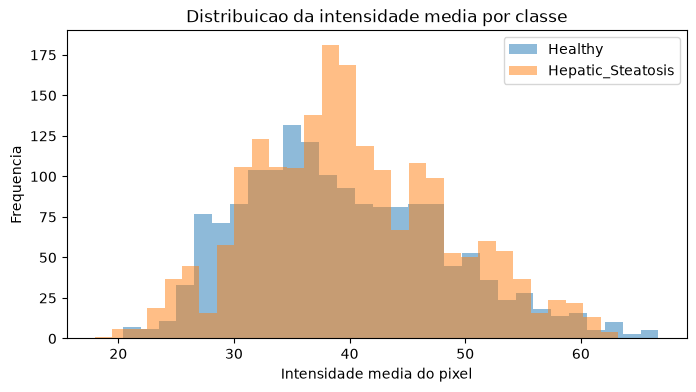

In [7]:
if audit_df is not None and "mean_intensity" in audit_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    for class_name, class_df in audit_df.groupby("class_name"):
        ax.hist(class_df["mean_intensity"].dropna(), bins=30, alpha=0.5, label=class_name)
    ax.set_title("Distribuicao da intensidade media por classe")
    ax.set_xlabel("Intensidade media do pixel")
    ax.set_ylabel("Frequencia")
    ax.legend()
    plt.show()


## Figuras ja geradas

Quando os scripts foram executados, as figuras em `reports/figures/` podem ser reaproveitadas diretamente na apresentacao.


eda_samples_by_class.png


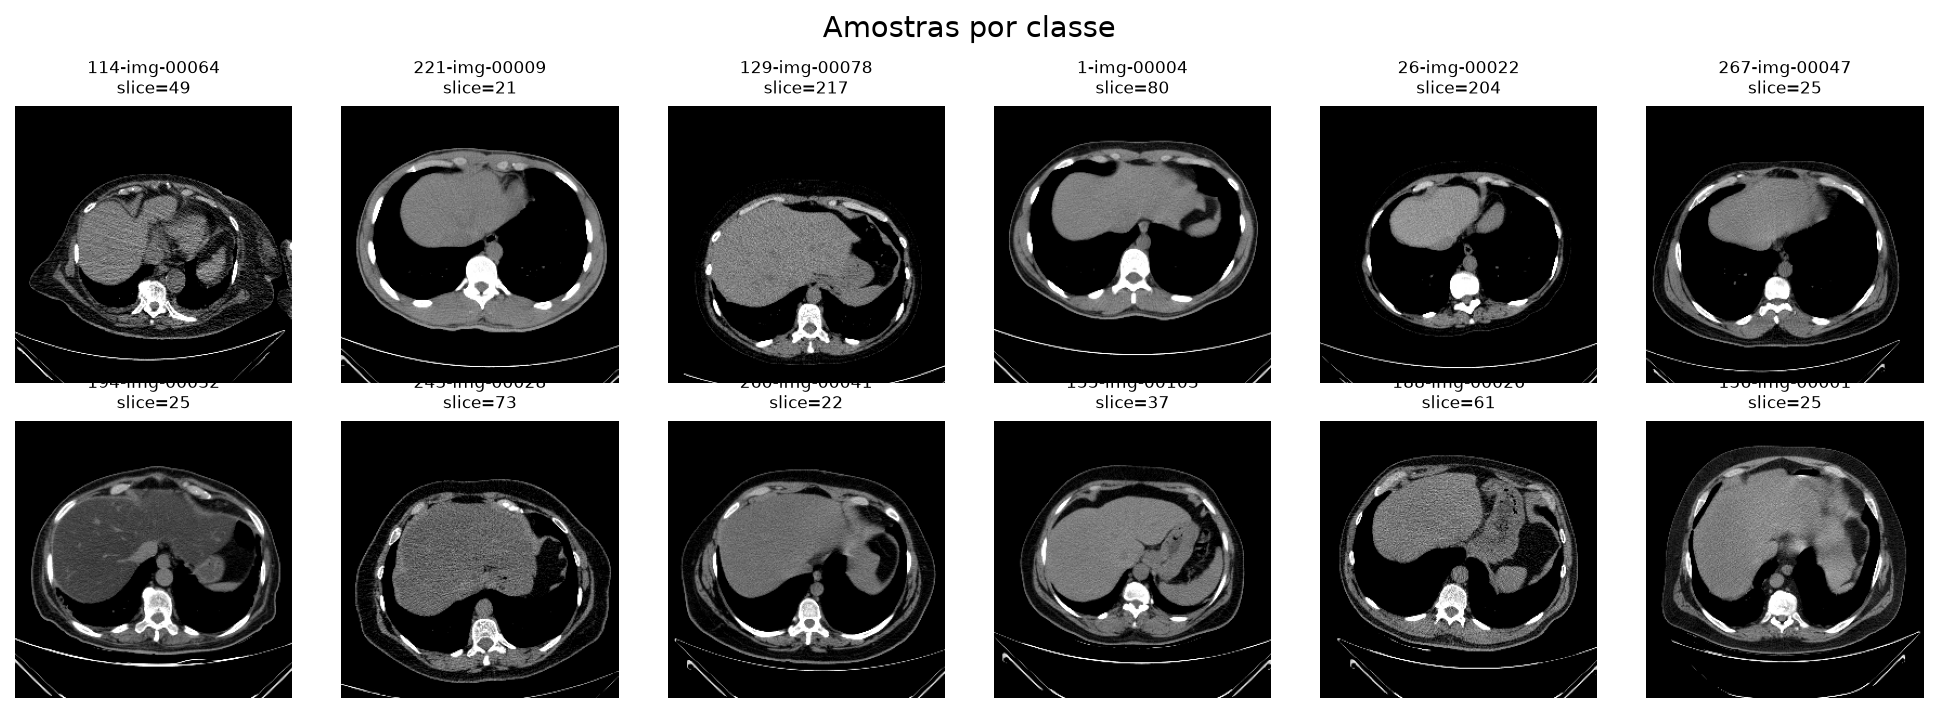

eda_samples_by_split_class.png


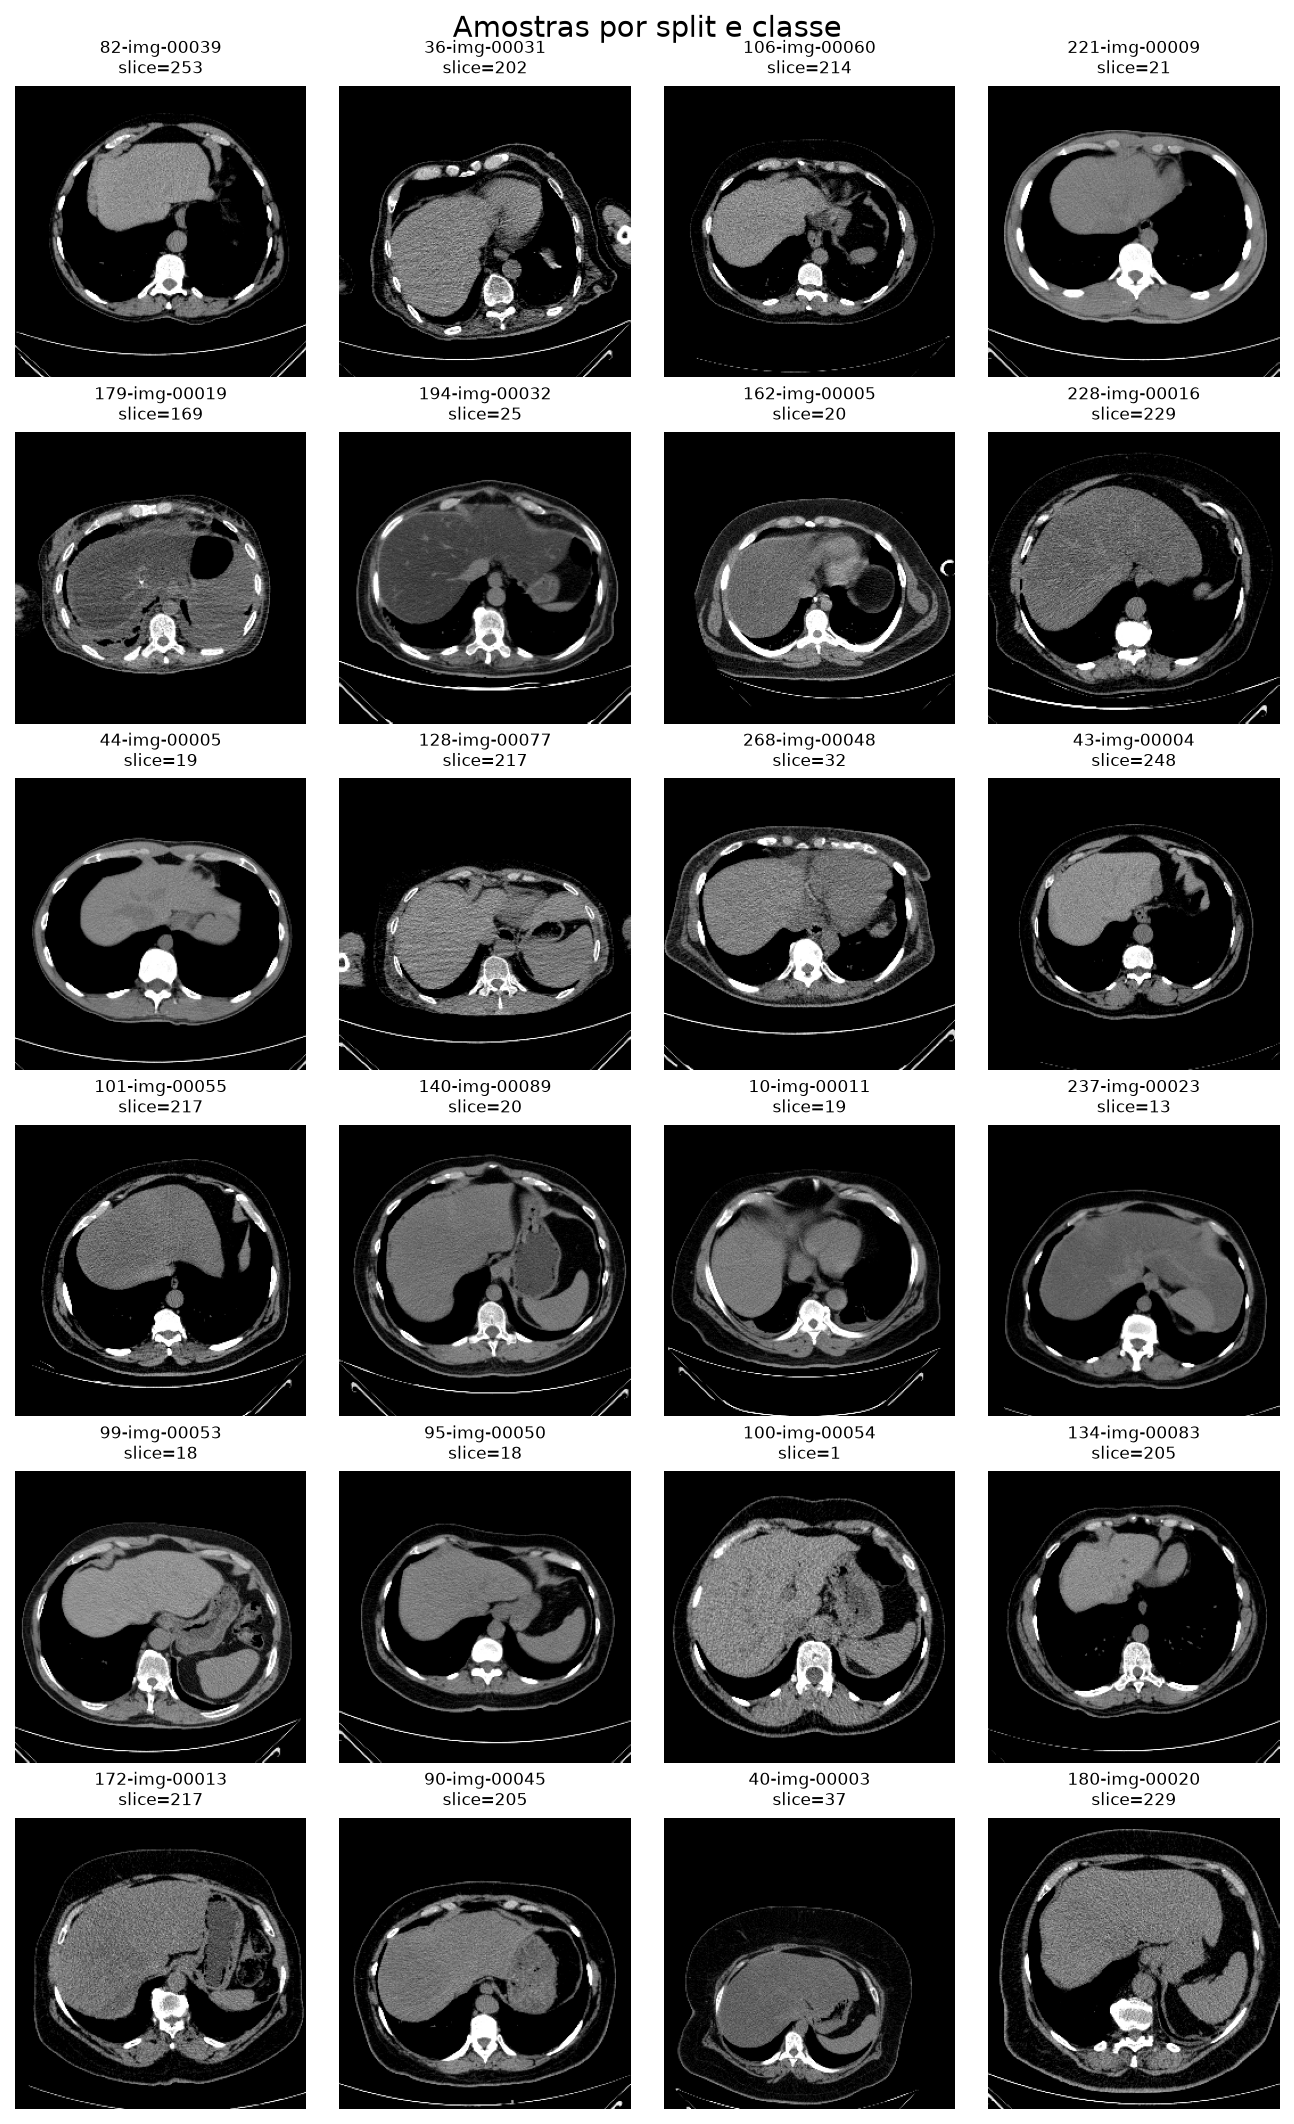

eda_mean_intensity_hist_by_class.png


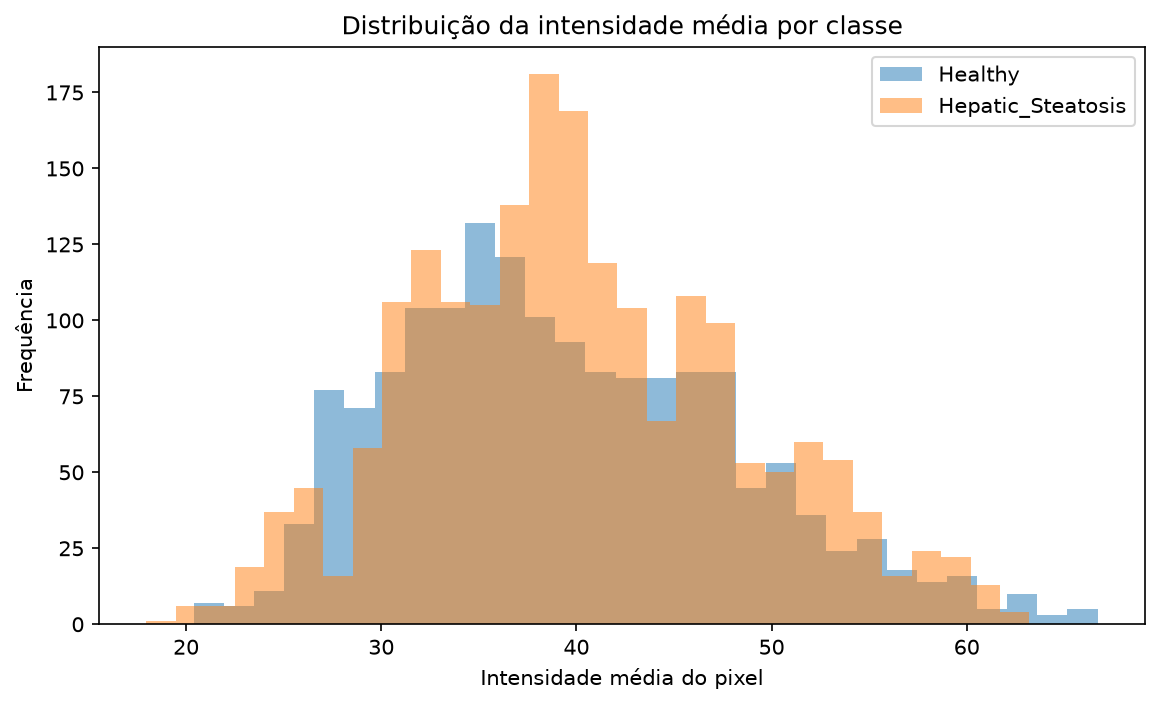

eda_file_size_hist_by_class.png


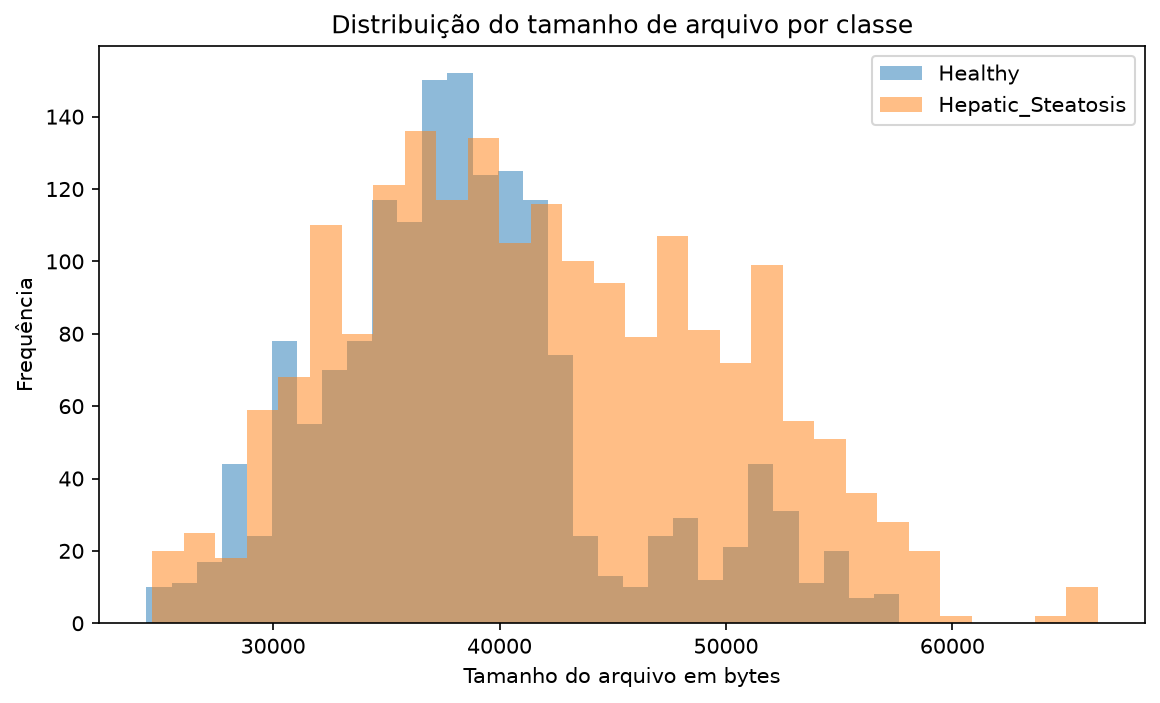

eda_mean_intensity_boxplot_by_class.png


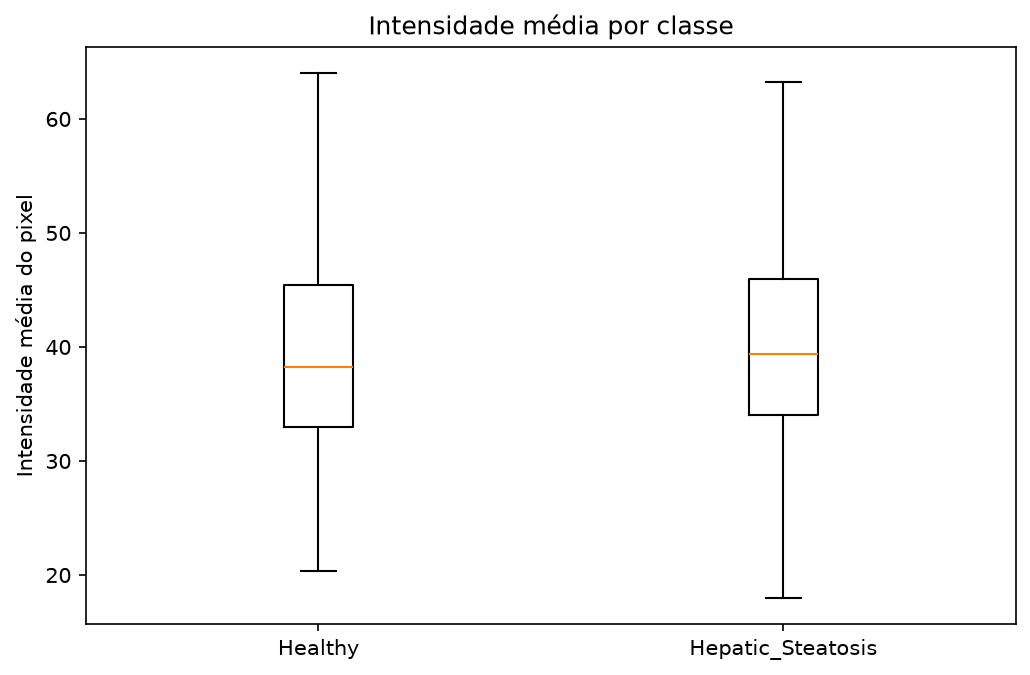

eda_file_size_boxplot_by_class.png


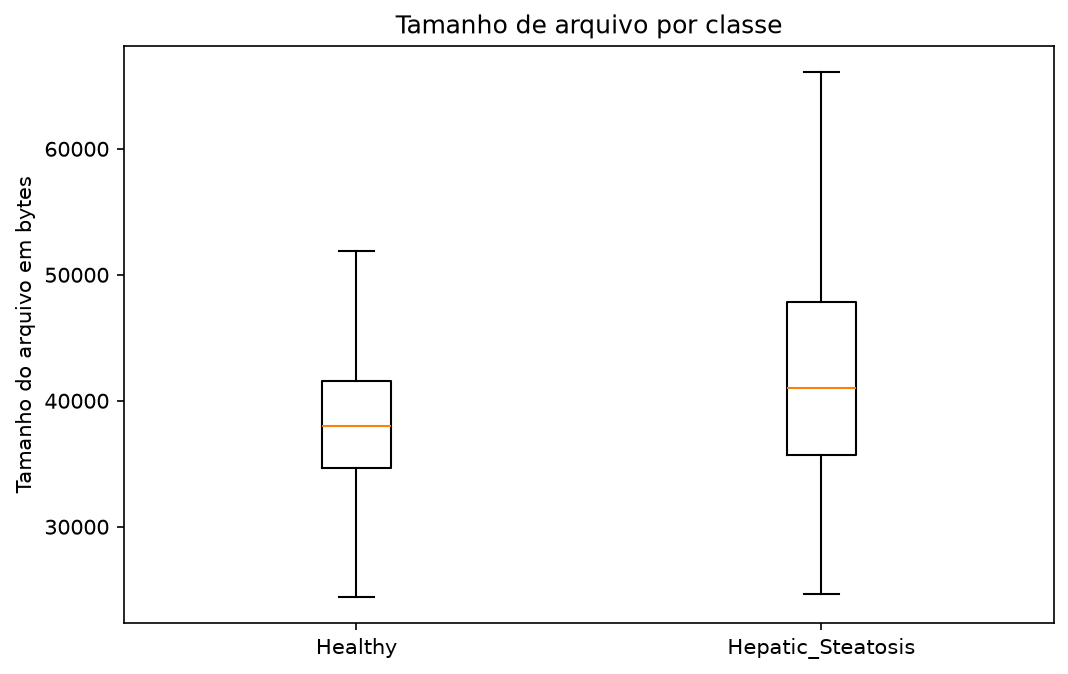

In [8]:
figure_names = [
    "eda_samples_by_class.png",
    "eda_samples_by_split_class.png",
    "eda_mean_intensity_hist_by_class.png",
    "eda_file_size_hist_by_class.png",
    "eda_mean_intensity_boxplot_by_class.png",
    "eda_file_size_boxplot_by_class.png",
]

for figure_name in figure_names:
    figure_path = REPORT_FIGURES / figure_name
    print(figure_name)
    if figure_path.exists():
        display(Image(filename=str(figure_path), width=900))
    else:
        print(f"Figura ainda nao encontrada: {figure_path}")


## Comparacoes por split e classe

Esta tabela ajuda a identificar se alguma diferenca tecnica aparece concentrada em treino, validacao ou teste.


In [9]:
if eda_by_split_class is not None:
    display(eda_by_split_class)
elif audit_df is not None and "split" in audit_df.columns:
    display(
        audit_df.groupby(["split", "class_name"])
        .agg(
            n_images=("filename", "count"),
            n_groups=("inferred_group_id", "nunique"),
            mean_intensity_avg=("mean_intensity", "mean"),
            std_intensity_avg=("std_intensity", "mean"),
            file_size_avg=("file_size_bytes", "mean"),
        )
        .round(4)
        .reset_index()
        .sort_values(["split", "class_name"])
    )


,split,class_name,n_images,n_groups,mean_intensity_avg,mean_intensity_std,std_intensity_avg,file_size_avg,file_size_std
0,test,Healthy,260,12,40.5170,9.1064,61.9478,40007.5885,5540.2290
1,test,Hepatic_Steatosis,300,23,43.1512,9.5561,59.7174,42006.1167,7921.3150
2,train,Healthy,1095,53,39.3134,8.3018,61.1031,38471.4831,6601.2994
3,train,Hepatic_Steatosis,1364,104,39.8037,7.9522,58.5942,41583.5711,8041.4054
4,val,Healthy,256,11,38.9155,9.6956,61.3331,37689.9805,6275.9651
5,val,Hepatic_Steatosis,282,22,38.3357,8.1833,57.2938,42584.2128,8415.8027


## Results

A EDA deve ser usada para organizar hipoteses e riscos, nao para concluir validade clinica. Pontos a observar: desbalanceamento por slice e por grupo, variacao de numero de slices por agrupamento, sobreposicao ou diferencas nas estatisticas de intensidade, diferencas tecnicas como tamanho de arquivo e exemplos visuais que possam sugerir atalhos fora da regiao hepatica.


## Takeaways

Principais riscos para as proximas etapas:

- possivel desbalanceamento entre classes;
- variabilidade de slices por grupo;
- risco de atalhos visuais ou tecnicos;
- risco de avaliacao artificialmente otimista se a analise ignorar grupos;
- impossibilidade de interpretar intensidade JPEG como HU.

A modelagem deve continuar separando analise descritiva, preditiva e causal. Nesta etapa ha apenas analise descritiva.
